In [1]:
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os
from sqlalchemy import create_engine

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
seller_rating = '''SELECT oi.seller_id, ROUND(AVG(orv.review_score),2) AS seller_rating, SUM(oi.price) AS revenue
                   FROM order_items AS oi
                   INNER JOIN order_reviews AS orv
                   ON oi.order_id = orv.order_id
                   GROUP BY oi.seller_id;  '''
sr_df = pd.read_sql(seller_rating,engine)


In [3]:
sr_df['div'] = pd.cut(sr_df['seller_rating'],[0,4,6],labels=['bad(4-)','good(4+)'],right=False)


In [4]:
sm_df = sr_df.groupby('div').agg(
    total_revenue=('revenue', 'sum'),
    seller_count=('seller_id', 'count')
).reset_index()

We will use sr_df to plot seller_rating Vs revenue and sm_df to show revenue share by good(sellers with rating above 4) and bad sellers (sellers with rating below 4)

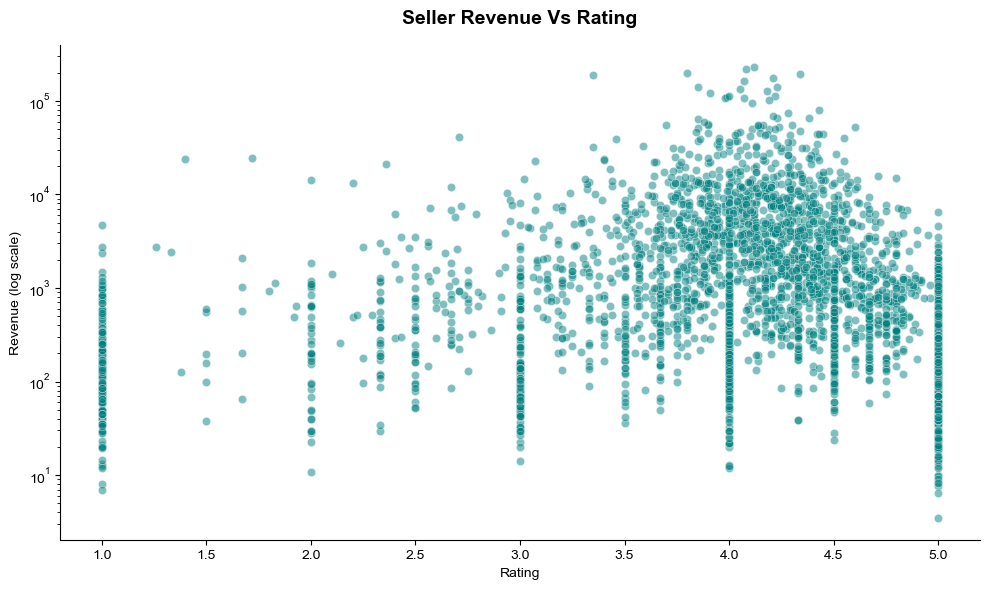

In [5]:
fig, ax = plt.subplots(figsize=(10,6))
sns.set_style('ticks')
sns.scatterplot(x='seller_rating',y='revenue',data=sr_df,alpha=0.5,color='teal')
ax.set_xlabel('Rating')
ax.set_ylabel('Revenue (log scale)')
ax.set_yscale('log')
ax.set_title('Seller Revenue Vs Rating', fontsize=14, weight='bold', pad=15)
sns.despine()
plt.tight_layout()
plt.show()


We have used a log scale for revenue which simply means that a dot stting one gridline above the other is making 10 times the revenue. This scatter plot shows us that the seller which make the most of the revenue are concentrated between 3-5 rating which tells us that customers do take into account the seller's rating before making a purchase.<br> One more thing to consider here is the single long grids we are getting at ratings 1.0,2.0,etc these are sellers with less number of orders hence their ratings are whole numbers.


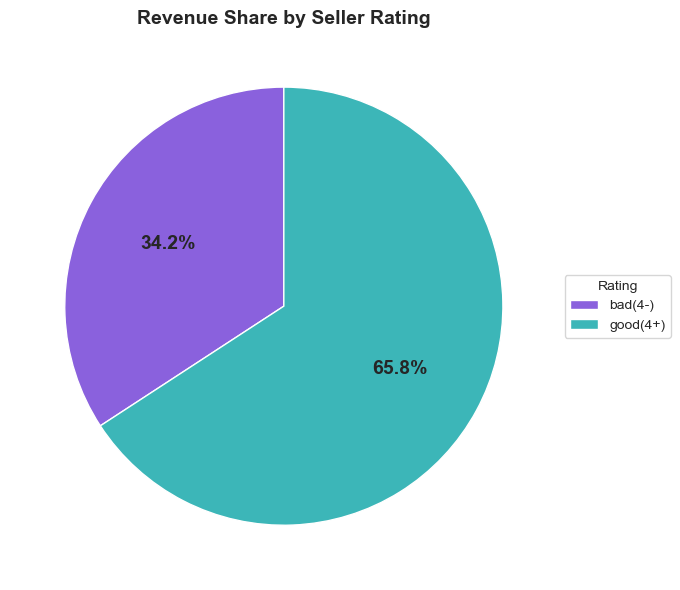

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.set_style('ticks')

wedges, texts, autotexts = ax.pie(
    x=sm_df['total_revenue'], 
    labels=None, 
    colors=["#8a61dd", "#3cb6b8"] ,
    autopct='%1.1f%%',
    startangle=90, 
    textprops={'fontsize': 14,'weight':'bold'}
)

ax.legend(
    wedges, 
    sm_df['div'],
    title="Rating",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title('Revenue Share by Seller Rating',fontsize=14,weight='bold')
plt.tight_layout()
plt.show()

Good Sellers : 1994 <br>
Bad Sellers : 1096 <br>
This shows us that while Good sellers do make more revenue, Their share is not disproportionately large.


In [7]:
# Exporting dataframe to csv for use in Tableau
sr_df.to_csv('/Volumes/Air/Olist_exports_tableau/Seller_rating_revenue.csv', index=False)

In [8]:
# Exporting dataframe to csv for use in Tableau
sm_df.to_csv('/Volumes/Air/Olist_exports_tableau/Seller_performance.csv', index=False)